# Potentiel photovoltaique tertiaire en France

**Workshop client Oxand** — analyse exploratoire du potentiel PV des toitures
tertiaires (9-500 kWc) a l'echelle departementale, focus rentabilite economique.

> Donnees de gisement : **PVGIS** (JRC, reelles). Hypotheses economiques :
> ordres de grandeur de la note de cadrage (Annexe A), explicitees dans `config.py`.


## 1. Chargement des donnees et du modele

In [1]:
import sys, os
# Se placer a la racine du projet pour que les imports et les chemins
# relatifs de config.py (data/...) fonctionnent, quel que soit le dossier de lancement.
_here = os.getcwd()
if os.path.basename(_here) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))
import pandas as pd
import geopandas as gpd
from src import config, economics as eco, viz
from src.dataset import build_dataset

# Reconstruit (utilise le cache PVGIS si present) et renvoie le GeoDataFrame
gdf = build_dataset()
print("Departements :", len(gdf))
print("Source gisement :", gdf["source"].value_counts().to_dict())
gdf[["code_dept", "nom_dept", "facteur_production", "source"]].head()

  Cache PVGIS trouve (96 departements).
Departements : 96
Source gisement : {'pvgis': 96}


C:\Users\ImeneBELHOCINE\OneDrive - Oxand\Bureau\école\workshop client\workshop\src\dataset.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = gdf.geometry.centroid


,code_dept,nom_dept,facteur_production,source
0,01,Ain,1180.46,pvgis
1,02,Aisne,1056.81,pvgis
2,03,Allier,1167.01,pvgis
3,04,Alpes-de-Haute-Provence,1376.95,pvgis
4,05,Hautes-Alpes,1171.39,pvgis


## 2. Calcul des indicateurs economiques par departement

Installation de reference : **100 kWc**, regime **autoconsommation**
(le plus rentable pour le tertiaire selon la note).

In [2]:
P = config.REF_POWER_KWC
REGIME = "autoconso"

def indicateurs(facteur):
    if pd.isna(facteur):
        return pd.Series({"production_MWh": None, "LCOE": None,
                          "payback": None, "TRI": None, "VAN": None})
    cf = eco.cashflows(P, facteur, REGIME)
    irr = eco.irr(cf)
    return pd.Series({
        "production_MWh": eco.annual_production(P, facteur, 1) / 1000,
        "LCOE": eco.lcoe(P, facteur),
        "payback": eco.payback(cf),
        "TRI": irr * 100 if irr is not None else None,
        "VAN": eco.npv(config.DISCOUNT_RATE, cf),
    })

ind = gdf["facteur_production"].apply(indicateurs)
gdf = gdf.join(ind)
gdf[["nom_dept", "facteur_production", "LCOE", "payback", "TRI", "VAN"]].describe()

,facteur_production,LCOE,payback,TRI,VAN
count,96.000000,96.000000,96.000000,96.000000,96.000000
mean,1160.773542,0.083981,5.708333,18.512278,201148.758557
std,96.893512,0.006469,0.479400,1.855802,28812.442550
min,1029.500000,0.065559,4.000000,15.968557,162113.003619
25%,1094.072500,0.080541,5.000000,17.232249,181314.407449
50%,1140.150000,0.084959,6.000000,18.125599,195016.102211
75%,1202.697500,0.088537,6.000000,19.328866,213615.348113
max,1477.530000,0.094090,6.000000,24.525487,295340.073315


## 3. Cartes du potentiel

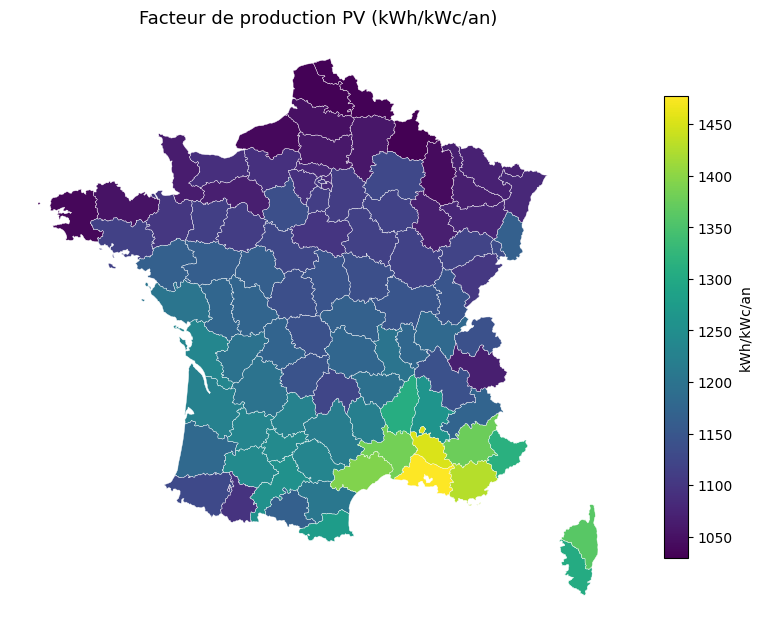

In [3]:
viz.choropleth(gdf, "facteur_production",
    "Facteur de production PV (kWh/kWc/an)", legend_label="kWh/kWc/an");

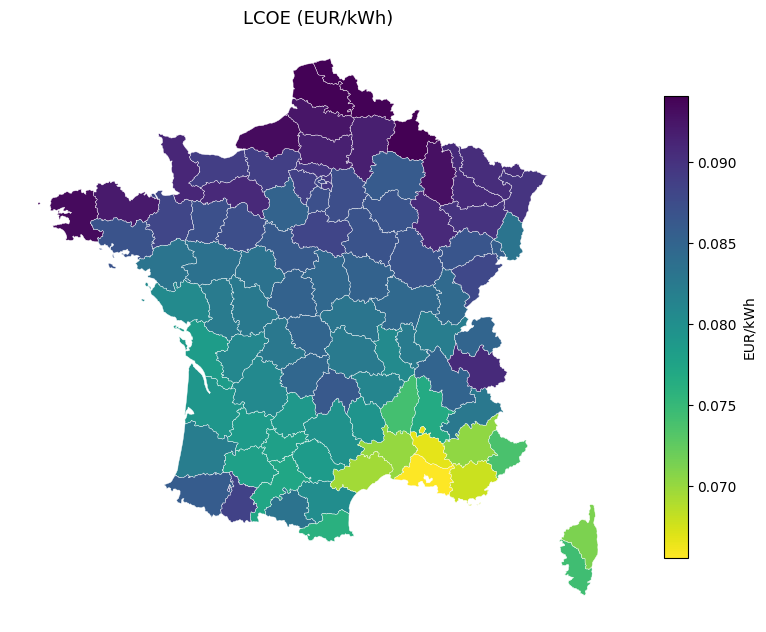

In [4]:
viz.choropleth(gdf, "LCOE", "LCOE (EUR/kWh)",
    cmap="viridis_r", legend_label="EUR/kWh");

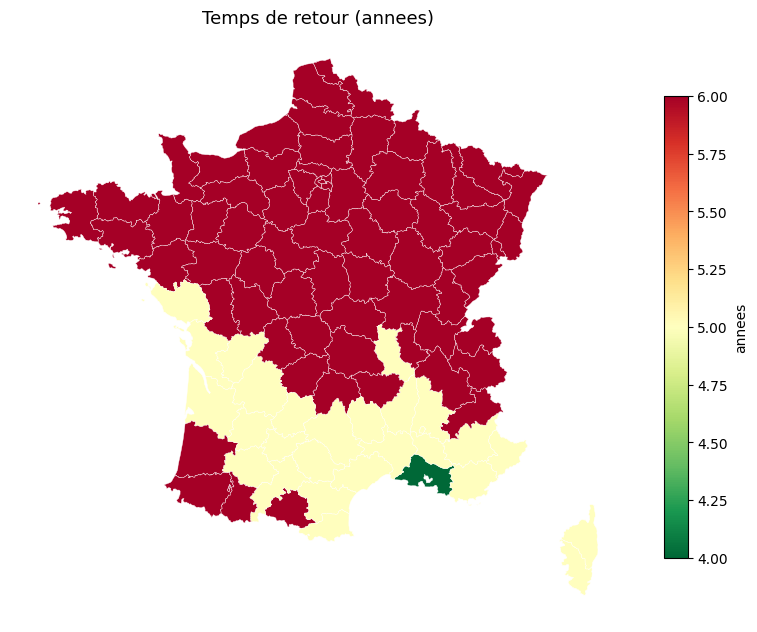

In [5]:
viz.choropleth(gdf, "payback", "Temps de retour (annees)",
    cmap="RdYlGn_r", legend_label="annees");

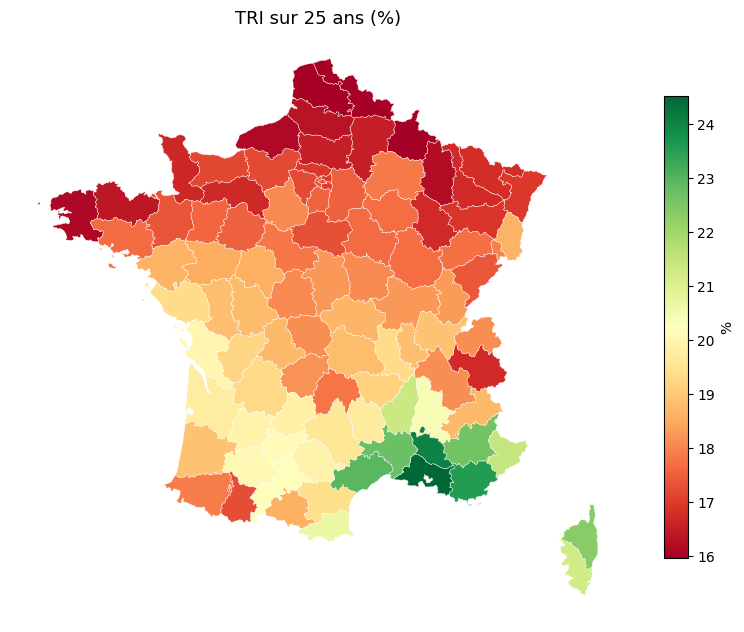

In [6]:
viz.choropleth(gdf, "TRI", "TRI sur 25 ans (%)",
    cmap="RdYlGn", legend_label="%");

## 4. Analyse de sensibilite

### 4.1 Effet d'echelle du CAPEX (EUR/kWc) selon la taille

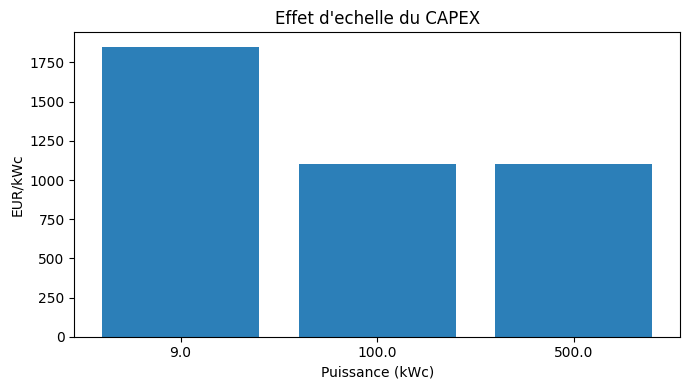

In [7]:
sizes = config.SENSITIVITY_SIZES_KWC
capex_unit = [eco.capex_per_kwc(s) for s in sizes]
viz.bar_chart(sizes, capex_unit,
    "Effet d'echelle du CAPEX", "Puissance (kWc)", "EUR/kWc");

### 4.2 Autoconsommation vs vente — payback pour un departement median

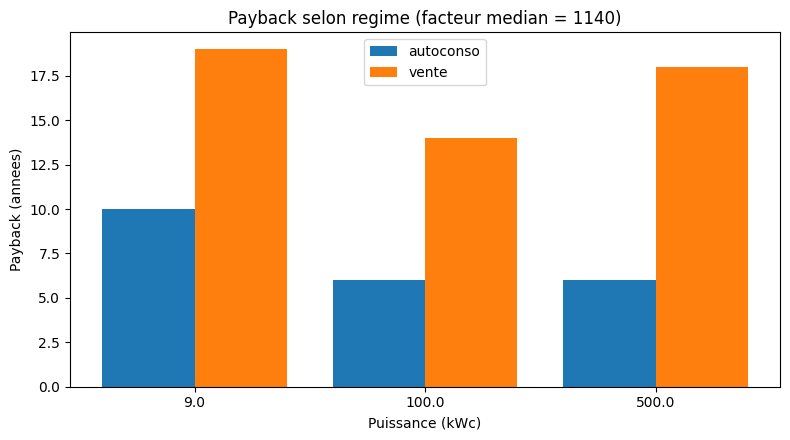

In [8]:
fac_med = gdf["facteur_production"].median()
pb = {r: [eco.payback(eco.cashflows(s, fac_med, r)) for s in sizes]
      for r in ("autoconso", "vente")}
viz.grouped_bar(sizes, pb,
    f"Payback selon regime (facteur median = {fac_med:.0f})",
    "Puissance (kWc)", "Payback (annees)");

### 4.3 Dispersion Nord / Sud du facteur de production

In [9]:
nord = gdf.nsmallest(5, "facteur_production")[["nom_dept", "facteur_production"]]
sud = gdf.nlargest(5, "facteur_production")[["nom_dept", "facteur_production"]]
print("5 plus faibles (Nord) :"); print(nord.to_string(index=False))
print("\n5 plus eleves (Sud) :"); print(sud.to_string(index=False))

5 plus faibles (Nord) :
      nom_dept  facteur_production
      Ardennes             1029.50
 Pas-de-Calais             1031.73
          Nord             1031.78
     Finistère             1037.23
Seine-Maritime             1039.08

5 plus eleves (Sud) :
        nom_dept  facteur_production
Bouches-du-Rhône             1477.53
        Vaucluse             1451.54
             Var             1427.17
         Hérault             1392.82
            Gard             1382.95


## 5. Limites et hypotheses

- **Gisement** : PVGIS, installation type (30 deg, Sud, pertes 14 %). Reel.
- **Couts/tarifs** : hypotheses (Annexe A), non specifiques au batiment.
- **Analyse agregee** : pas d'etude batiment par batiment (= role de Simeo).
- **Indicateurs** : calcules par le modele, reproductibles, auditables via `config.py`.

Ce notebook caracterise le *terrain de jeu* ; il ne constitue pas un module Simeo.
